# Bayesian Analysis with PyMC – Breast Cancer Wisconsin Dataset

## 1. Setup and Data Preparation

In [38]:
!pip install pymc arviz -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import pymc as pm
import arviz as az

from sklearn.datasets import load_breast_cancer

In [39]:
data = load_breast_cancer()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


##1. Dataset and Research Question

The dataset contains measurements of breast cancer tumors classified as either malignant or benign.

For the Bayesian analysis, we will first estimate the probability that a randomly selected tumor in the dataset is malignant.

In [40]:
print("Target names:", data.target_names)

df["malignant"] = 1 - df["target"]

print("\nClass counts:")
print(df["malignant"].value_counts())

print("\nProportion malignant:")
print(df["malignant"].mean())

Target names: ['malignant' 'benign']

Class counts:
malignant
0    357
1    212
Name: count, dtype: int64

Proportion malignant:
0.37258347978910367


## 2. Bayesian Estimation of the Malignant Probability

Let \(p\) represent the probability that a randomly selected tumor from this dataset is malignant.

We model each observation as a Bernoulli random variable and use a Beta prior for \(p\).

### AI Question

**Why is the Beta distribution a natural prior for a Bernoulli probability, and what does a Beta(1,1) prior represent?**

In [41]:
n = len(df)
malignant_count = df["malignant"].sum()

alpha_prior = 1
beta_prior = 1

alpha_post = alpha_prior + malignant_count
beta_post = beta_prior + (n - malignant_count)

print("Number of observations:", n)
print("Number malignant:", malignant_count)
print("Posterior distribution: Beta(", alpha_post, ",", beta_post, ")")

Number of observations: 569
Number malignant: 212
Posterior distribution: Beta( 213 , 358 )


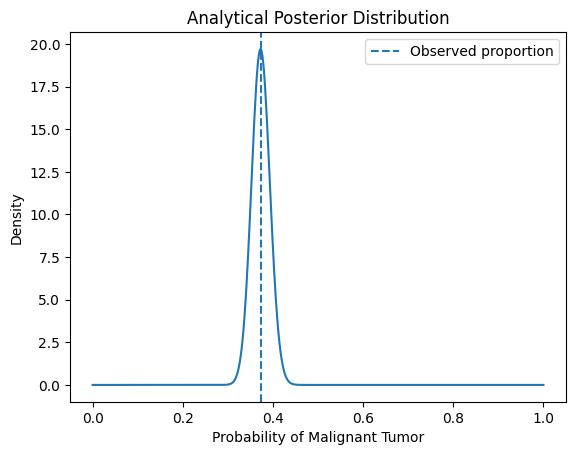

In [42]:
x = np.linspace(0, 1, 500)

posterior_pdf = stats.beta.pdf(
    x,
    alpha_post,
    beta_post
)

plt.plot(x, posterior_pdf)
plt.axvline(
    malignant_count / n,
    linestyle="--",
    label="Observed proportion"
)

plt.xlabel("Probability of Malignant Tumor")
plt.ylabel("Density")
plt.title("Analytical Posterior Distribution")
plt.legend()
plt.show()

### Interpretation

The posterior distribution is concentrated around 0.37, which is very close to the observed malignant proportion in the dataset.

Because the dataset contains 569 observations, the posterior distribution is relatively narrow, indicating fairly low uncertainty about the estimated probability.

### AI Question

**How does sequential Bayesian updating work in a Beta-Bernoulli model, and why does processing the observations one at a time lead to the same final posterior as processing all observations at once?**


### Sequential Bayesian Updating

Bayesian inference can also be performed sequentially.

Starting from the prior \(Beta(1,1)\), each new tumor observation updates the posterior distribution. A malignant observation increases the \(\alpha\) parameter, while a benign observation increases the \(\beta\) parameter.

This demonstrates that the posterior after one step can be used as the prior for the next step.



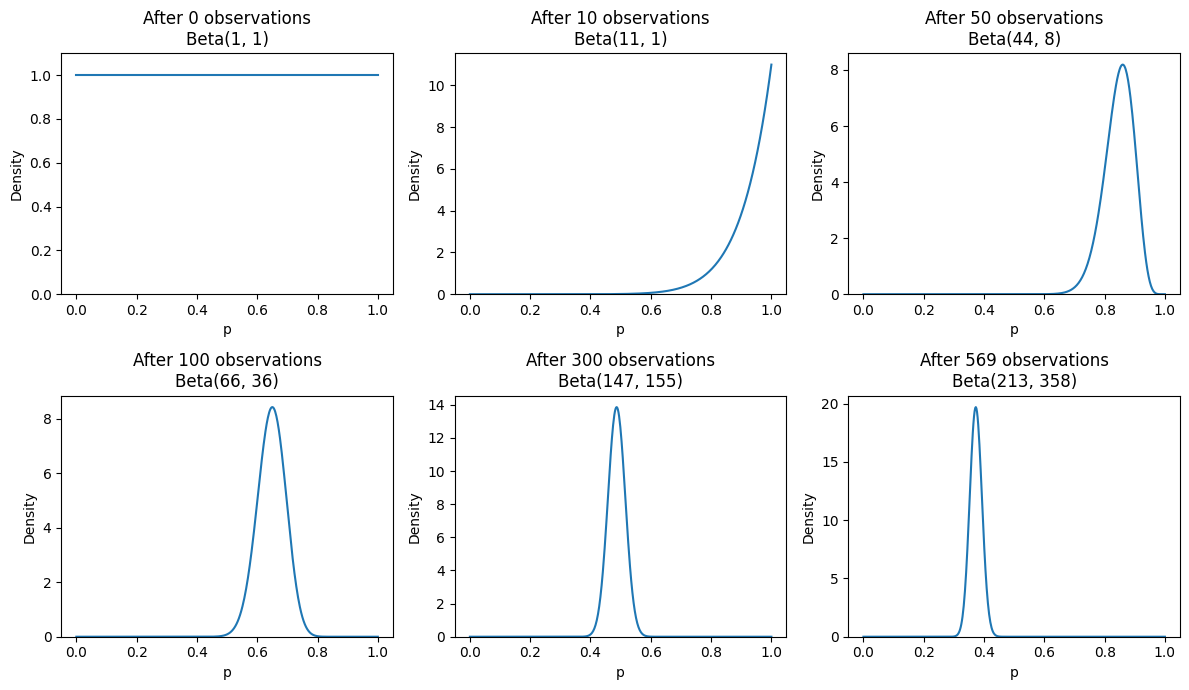

In [43]:
observations = df["malignant"].values

checkpoints = [0, 10, 50, 100, 300, len(observations)]
p_grid = np.linspace(0, 1, 500)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax, n_obs in zip(axes.flatten(), checkpoints):

    observed_data = observations[:n_obs]

    alpha_current = 1 + observed_data.sum()
    beta_current = 1 + n_obs - observed_data.sum()

    posterior = stats.beta.pdf(
        p_grid,
        alpha_current,
        beta_current
    )

    ax.plot(p_grid, posterior)
    ax.set_title(
        f"After {n_obs} observations\n"
        f"Beta({int(alpha_current)}, {int(beta_current)})"
    )
    ax.set_xlabel("p")
    ax.set_ylabel("Density")
    if n_obs == 0:
             ax.set_ylim(0, 1.1)
    else:
           ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

### Interpretation

The posterior distribution changes as more observations are added.

With only a small number of observations, the posterior is strongly affected by the specific early observations and remains relatively uncertain.

As more data are accumulated, the posterior becomes increasingly concentrated and stabilizes near the observed malignant proportion.

After all 569 observations, the sequential update produces the same final posterior, \(Beta(213,358)\), as the batch calculation performed earlier.

## 3. Bayesian Estimation with PyMC and MCMC

### AI Question

**What is MCMC, and how can it be used to approximate a posterior distribution without explicitly calculating the normalizing constant \(P(data)\)? In this example the posterior has a known analytical form, so why is it still useful to estimate it with MCMC?**

In [44]:
with pm.Model() as model:

    p = pm.Beta(
        "p",
        alpha=1,
        beta=1
    )

    y = pm.Bernoulli(
        "y",
        p=p,
        observed=df["malignant"].values
    )

    idata = pm.sample(
        2000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )

az.summary(
    idata,
    var_names=["p"],
    hdi_prob=0.95
)

Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.373,0.02,0.332,0.41,0.0,0.0,3430.0,5391.0,1.0


### Model Structure

The probabilistic structure of the Beta-Bernoulli model can be visualized using PyMC.

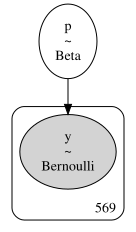

In [45]:
pm.model_to_graphviz(model)

### Interpretation

The PyMC posterior mean for the malignant probability is approximately 0.373, which closely matches the analytical posterior estimate.

The 95% HDI ranges from approximately 0.332 to 0.410.

The MCMC diagnostics indicate good convergence: `r_hat` is 1.0, the effective sample sizes are high, and no divergences were observed.

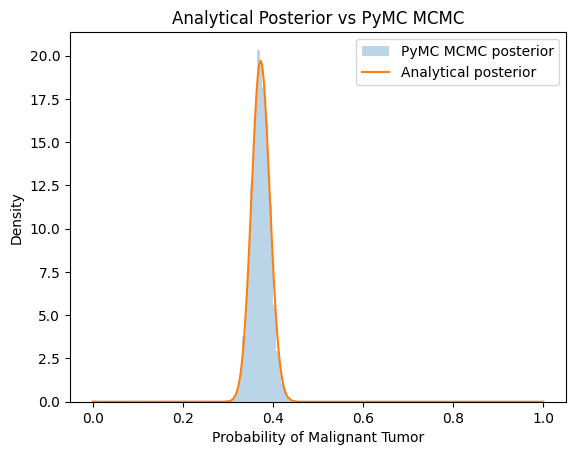

In [46]:
posterior_samples = idata.posterior["p"].values.flatten()

plt.hist(
    posterior_samples,
    bins=40,
    density=True,
    alpha=0.3,
    label="PyMC MCMC posterior"
)

plt.plot(
    x,
    posterior_pdf,
    label="Analytical posterior"
)

plt.xlabel("Probability of Malignant Tumor")
plt.ylabel("Density")
plt.title("Analytical Posterior vs PyMC MCMC")
plt.legend()
plt.show()

### Interpretation

The analytical posterior and the PyMC MCMC posterior almost completely overlap.

This confirms that the MCMC approximation closely reproduces the exact Bayesian posterior in this case.

### Posterior Distribution and HDI

The posterior distribution of \(p\) can be visualized directly together with its 95% highest density interval (HDI).

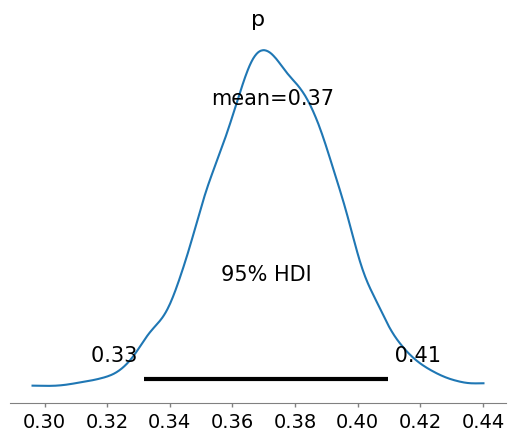

In [47]:
az.plot_posterior(
    idata,
    var_names=["p"],
    hdi_prob=0.95
)

plt.show()

### Interpretation

The posterior distribution is centered around 0.373.

The 95% HDI shows the range of the most credible values for the malignant probability, which is approximately consistent with the interval obtained from the posterior summary.

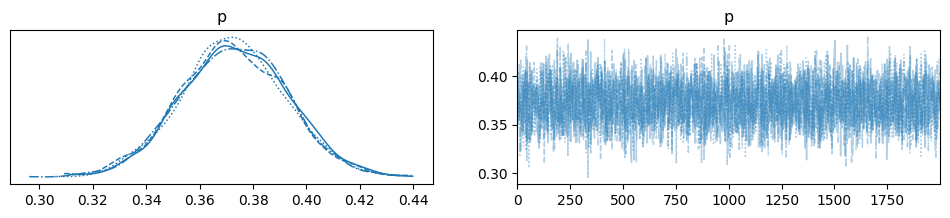

In [48]:
az.plot_trace(
    idata,
    var_names=["p"]
)

plt.show()

### MCMC Diagnostics

The trace plot shows that the chains overlap well and fluctuate around a stable range without a visible trend.

Together with an `r_hat` value of 1.0 and the absence of divergences, this indicates good MCMC convergence.

### Bayes Point Estimators

### AI Question

**What is the difference between a general point estimate and a Bayes estimator, and how are the posterior mean and median related to different loss functions?**

A Bayesian posterior distribution contains the full uncertainty about a parameter, but in some applications a single point estimate is still useful.

Under squared-error loss (L2), the optimal Bayes estimator is the posterior mean.

Under absolute-error loss (L1), the optimal Bayes estimator is the posterior median.

In [49]:
posterior_samples = idata.posterior["p"].values.flatten()

x_loss = np.linspace(0.30, 0.45, 500)

L2 = np.mean(
    (posterior_samples.reshape(-1, 1) - x_loss.reshape(1, -1))**2,
    axis=0
)

L1 = np.mean(
    np.abs(posterior_samples.reshape(-1, 1) - x_loss.reshape(1, -1)),
    axis=0
)

print("L2 minimizing estimate:", x_loss[L2.argmin()])
print("Posterior mean:", posterior_samples.mean())

print("L1 minimizing estimate:", x_loss[L1.argmin()])
print("Posterior median:", np.median(posterior_samples))

L2 minimizing estimate: 0.3727454909819639
Posterior mean: 0.37277403990800134
L1 minimizing estimate: 0.37244488977955914
Posterior median: 0.37260349854294894


### Interpretation

The estimate that minimizes the L2 loss is almost identical to the posterior mean.

Similarly, the estimate that minimizes the L1 loss is very close to the posterior median.

This illustrates the connection between Bayes estimators and loss functions: the posterior mean is optimal under squared-error loss, while the posterior median is optimal under absolute-error loss.

## 4. Bayesian vs. Classical Estimation

### AI Question

**What is the difference between a Bayesian credible interval and a frequentist confidence interval?**

In [50]:
p_hat = malignant_count / n

z = stats.norm.ppf(0.975)

standard_error = np.sqrt(
    p_hat * (1 - p_hat) / n
)

ci_lower = p_hat - z * standard_error
ci_upper = p_hat + z * standard_error

print("Observed proportion:", p_hat)
print("95% Classical Confidence Interval:", (ci_lower, ci_upper))

Observed proportion: 0.37258347978910367
95% Classical Confidence Interval: (np.float64(0.33285684938465654), np.float64(0.4123101101935508))


### Interpretation

The classical estimate of the malignant proportion is approximately 0.373, with a 95% confidence interval from about 0.333 to 0.412.

The Bayesian posterior mean and 95% HDI are very similar.

In this case, the two approaches give almost identical numerical results because the sample size is relatively large and the prior is weakly informative.

### Bootstrap Confidence Interval

As an additional classical approach, we use bootstrap resampling to estimate the uncertainty of the malignant proportion.
### AI Question

**How does bootstrap resampling estimate uncertainty without assuming a specific parametric distribution, and how should a bootstrap confidence interval be interpreted?**

In [51]:
bootstrap_result = stats.bootstrap(
    (df["malignant"].values,),
    np.mean,
    confidence_level=0.95,
    random_state=42
)

print("Bootstrap estimate:", df["malignant"].mean())
print("95% Bootstrap Confidence Interval:",
      bootstrap_result.confidence_interval)

Bootstrap estimate: 0.37258347978910367
95% Bootstrap Confidence Interval: ConfidenceInterval(low=np.float64(0.3321616871704745), high=np.float64(0.4130052724077329))


### Bootstrap Interpretation

The bootstrap estimate of the malignant proportion is approximately 0.373.

The 95% bootstrap confidence interval ranges from approximately 0.332 to 0.413.

This interval is very similar to the classical normal-approximation confidence interval, suggesting that both classical approaches give consistent estimates of the uncertainty.

## 5. Posterior Predictive Distribution

### AI Question

**What is the difference between the posterior distribution of `p` and the posterior predictive distribution of future malignant outcomes? In this Beta-Bernoulli model, how is the Beta-Binomial distribution related to prediction, and is posterior predictive sampling itself an MCMC procedure?**

Output()

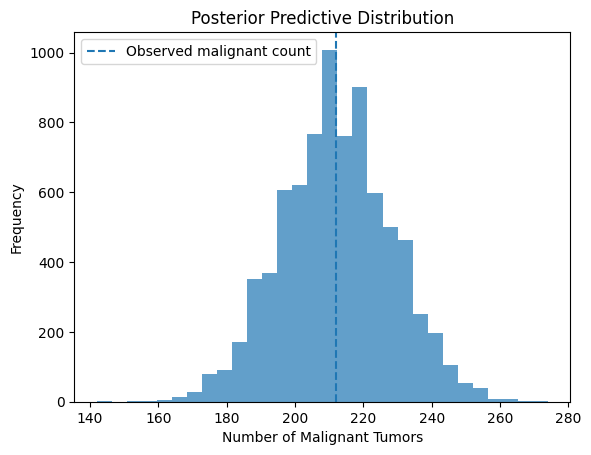

In [52]:
with model:
    posterior_predictive = pm.sample_posterior_predictive(
        idata,
        var_names=["y"],
        random_seed=42
    )

predicted_counts = (
    posterior_predictive.posterior_predictive["y"]
    .sum(dim="y_dim_0")
    .values
    .flatten()
)

plt.hist(
    predicted_counts,
    bins=30,
    alpha=0.7
)

plt.axvline(
    malignant_count,
    linestyle="--",
    label="Observed malignant count"
)

plt.xlabel("Number of Malignant Tumors")
plt.ylabel("Frequency")
plt.title("Posterior Predictive Distribution")
plt.legend()
plt.show()

### Interpretation

The observed number of malignant tumors (212) lies near the center of the posterior predictive distribution.

This suggests that the Bayesian model can generate outcomes that are consistent with the observed data.

## 6. Bayesian Hypothesis Testing – Bayes Factor

We test:

- **H0:** \(p = 0.5\)
- **H1:** \(p \neq 0.5\)


### AI Question

**What is a Bayes Factor, and how is its interpretation different from a frequentist p-value? In this model, what are \(H_0\) and \(H_1\), how can the Savage-Dickey density ratio be used to estimate the Bayes Factor, and what are some important limitations of this approach?**

The reference value is outside of the posterior. This translate into infinite support for H1, which is most likely an overstatement.


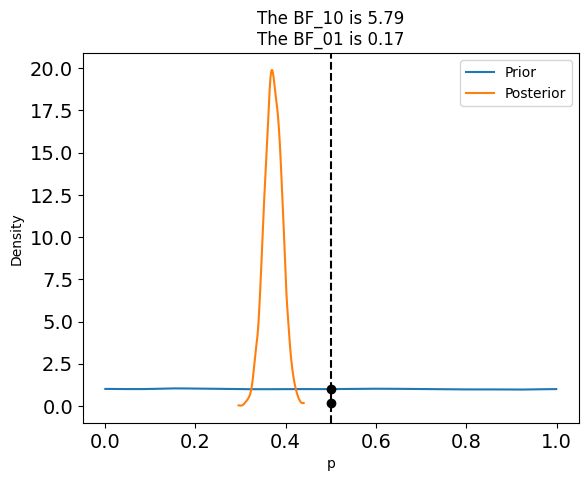

In [53]:
rng = np.random.default_rng(42)

prior_samples = rng.uniform(0, 1, 10000)

bf = az.plot_bf(
    idata,
    var_name="p",
    prior=prior_samples,
    ref_val=0.5
)

plt.show()

### Analytical Check of the Bayes Factor

Because this Beta-Bernoulli model has an analytical posterior, the Bayes Factor can also be checked directly using the Savage-Dickey density ratio.

This provides a useful check of the numerical estimate produced by `az.plot_bf`.

In [54]:
prior_density_h0 = stats.beta.pdf(
    0.5,
    alpha_prior,
    beta_prior
)

posterior_density_h0 = stats.beta.pdf(
    0.5,
    alpha_post,
    beta_post
)

bf01_exact = posterior_density_h0 / prior_density_h0
bf10_exact = 1 / bf01_exact

print("Exact BF_01:", bf01_exact)
print("Exact BF_10:", bf10_exact)

Exact BF_01: 1.5194517340972238e-07
Exact BF_10: 6581321.259237932


### Interpretation

The numerical Bayes Factor produced by `az.plot_bf` was approximately 5.8 in favor of \(H_1\), but the function also issued a warning that the reference value \(p=0.5\) lies outside the main posterior region.

Because this Beta-Bernoulli model has an analytical posterior, the Savage-Dickey density ratio can be computed directly.

The analytical calculation gives \(BF_{10} \approx 6.58 \times 10^6\), indicating very strong relative evidence for \(H_1\) over \(H_0\) under the chosen prior and model.

The large discrepancy shows that numerical Bayes Factor estimates can become unstable when the null value lies in an extreme tail of the posterior. Therefore, the warning from `az.plot_bf` should not be ignored.

A Bayes Factor compares the relative evidence for two models; it should not be interpreted as the probability that \(H_1\) is true.

In [55]:
classical_test = stats.binomtest(
    malignant_count,
    n,
    p=0.5,
    alternative="two-sided"
)

print("Classical p-value:", classical_test.pvalue)

Classical p-value: 1.2880634834639464e-09


### Classical vs. Bayesian Hypothesis Testing

The classical binomial test produced a very small p-value
(\(p \approx 1.29 \times 10^{-9}\)), so the null hypothesis \(p = 0.5\)
is rejected at the 0.05 significance level.

Both the classical test and the Bayes Factor provide evidence against
\(H_0\), although they quantify evidence in different ways.

The p-value measures how unusual the observed data would be under
\(H_0\), while the Bayes Factor compares the relative support for
\(H_1\) and \(H_0\).

## 7. Multiple Groups and Hierarchical Bayesian Modeling

To extend the analysis beyond a single malignant probability, tumors are divided into three groups according to their mean radius.

We will compare the malignant probability across the three groups and then fit a hierarchical Bayesian model.

In [56]:
df["radius_group"] = pd.qcut(
    df["mean radius"],
    q=3,
    labels=["Small", "Medium", "Large"]
)

group_summary = df.groupby(
    "radius_group",
    observed=True
)["malignant"].agg(["count", "sum", "mean"])

group_summary.columns = [
    "Number of tumors",
    "Malignant tumors",
    "Malignant proportion"
]

group_summary

,Number of tumors,Malignant tumors,Malignant proportion
radius_group,,,
Small,191,6,0.031414
Medium,188,39,0.207447
Large,190,167,0.878947


### Group Comparison

The observed malignant proportion increases strongly with mean radius:

- Small tumors: approximately 3.1% malignant
- Medium tumors: approximately 20.7% malignant
- Large tumors: approximately 87.9% malignant

We first estimate a separate malignant probability for each group.

### Classical Comparison – Chi-Square Test

As a classical approach, we test whether tumor malignancy is associated with the mean-radius group.

### AI Question

**What is the null hypothesis of a chi-square test of independence, what assumptions does the test require, and how should the p-value be interpreted?**

In [57]:
contingency_table = pd.crosstab(
    df["radius_group"],
    df["malignant"]
)

chi2_result = stats.chi2_contingency(contingency_table)

print("Contingency table:")
print(contingency_table)

print("\nChi-square statistic:", chi2_result.statistic)
print("p-value:", chi2_result.pvalue)
print("Degrees of freedom:", chi2_result.dof)

print("\nExpected frequencies:")
print(chi2_result.expected_freq)

Contingency table:
malignant       0    1
radius_group          
Small         185    6
Medium        149   39
Large          23  167

Chi-square statistic: 325.4354164758156
p-value: 2.150786017083972e-71
Degrees of freedom: 2

Expected frequencies:
[[119.83655536  71.16344464]
 [117.9543058   70.0456942 ]
 [119.20913884  70.79086116]]


### Classical Test – Interpretation

The chi-square test produced a very large test statistic
(\(\chi^2 \approx 325.44\)) and an extremely small p-value
(\(p \approx 2.15 \times 10^{-71}\)).

Therefore, the null hypothesis of independence is rejected, indicating a strong association between mean-radius group and tumor malignancy in this dataset.

All expected cell frequencies are well above 5, so the usual expected-frequency condition for the chi-square approximation is satisfied.

This classical result is consistent with the Bayesian group analysis, which also estimates substantially different malignant probabilities across the three radius groups.

In [58]:
group_names = ["Small", "Medium", "Large"]

df["radius_group"] = pd.Categorical(
    df["radius_group"],
    categories=group_names,
    ordered=True
)

group_idx = df["radius_group"].cat.codes.values

with pm.Model() as independent_model:

    p_group = pm.Beta(
        "p_group",
        alpha=1,
        beta=1,
        shape=3
    )

    y = pm.Bernoulli(
        "y",
        p=p_group[group_idx],
        observed=df["malignant"].values
    )

    idata_ind = pm.sample(
        2000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )

az.summary(
    idata_ind,
    var_names=["p_group"],
    hdi_prob=0.95
)

Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p_group[0],0.036,0.013,0.011,0.062,0.0,0.0,10385.0,5684.0,1.0
p_group[1],0.210,0.029,0.153,0.266,0.0,0.0,11235.0,5921.0,1.0
p_group[2],0.875,0.024,0.827,0.919,0.0,0.0,10976.0,5993.0,1.0


### Independent Group Model – Interpretation

The independent Bayesian model estimates very different malignant probabilities across the three radius groups.

- Small: posterior mean ≈ 0.036
- Medium: posterior mean ≈ 0.210
- Large: posterior mean ≈ 0.875

The MCMC diagnostics indicate good convergence, with `r_hat = 1.0` for all three group probabilities.

### Hierarchical Bayesian Model

### AI Question

**What is a hierarchical Bayesian model, what is a hyperprior, and how do the \( \mu \) and \( \nu \) parameters of the Beta distribution differ from the \( \alpha \) and \( \beta \) parameterization? Why can sharing information across groups lead to shrinkage, and what are possible limitations of shrinkage?**

In [59]:
with pm.Model() as hierarchical_model:

    mu = pm.Beta(
        "mu",
        alpha=2,
        beta=2
    )

    nu = pm.HalfNormal(
        "nu",
        sigma=30
    )

    p_group_h = pm.Beta(
        "p_group",
        mu=mu,
        nu=nu,
        shape=3
    )

    y = pm.Bernoulli(
        "y",
        p=p_group_h[group_idx],
        observed=df["malignant"].values
    )

    idata_h = pm.sample(
        2000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )

az.summary(
    idata_h,
    var_names=["mu", "nu", "p_group"],
    hdi_prob=0.95
)

Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.414,0.133,0.164,0.674,0.002,0.001,7918.0,6051.0,1.0
nu,1.929,1.149,0.282,4.239,0.013,0.018,7127.0,5865.0,1.0
p_group[0],0.035,0.013,0.012,0.062,0.000,0.000,7536.0,5222.0,1.0
p_group[1],0.210,0.030,0.152,0.267,0.000,0.000,8803.0,5933.0,1.0
p_group[2],0.874,0.024,0.826,0.917,0.000,0.000,7334.0,6003.0,1.0


### Hierarchical Model – Interpretation

The hierarchical model produces estimates that are very similar to those from the independent model.

Only a small amount of shrinkage is observed. This is reasonable because each radius group contains a relatively large number of observations, so the group-specific data provide strong information about each probability.

The hierarchical parameters describe the shared distribution from which the three group probabilities are estimated.

### Posterior Comparison of Group Probabilities

The posterior distributions of the three group probabilities can be compared between the independent and hierarchical models.

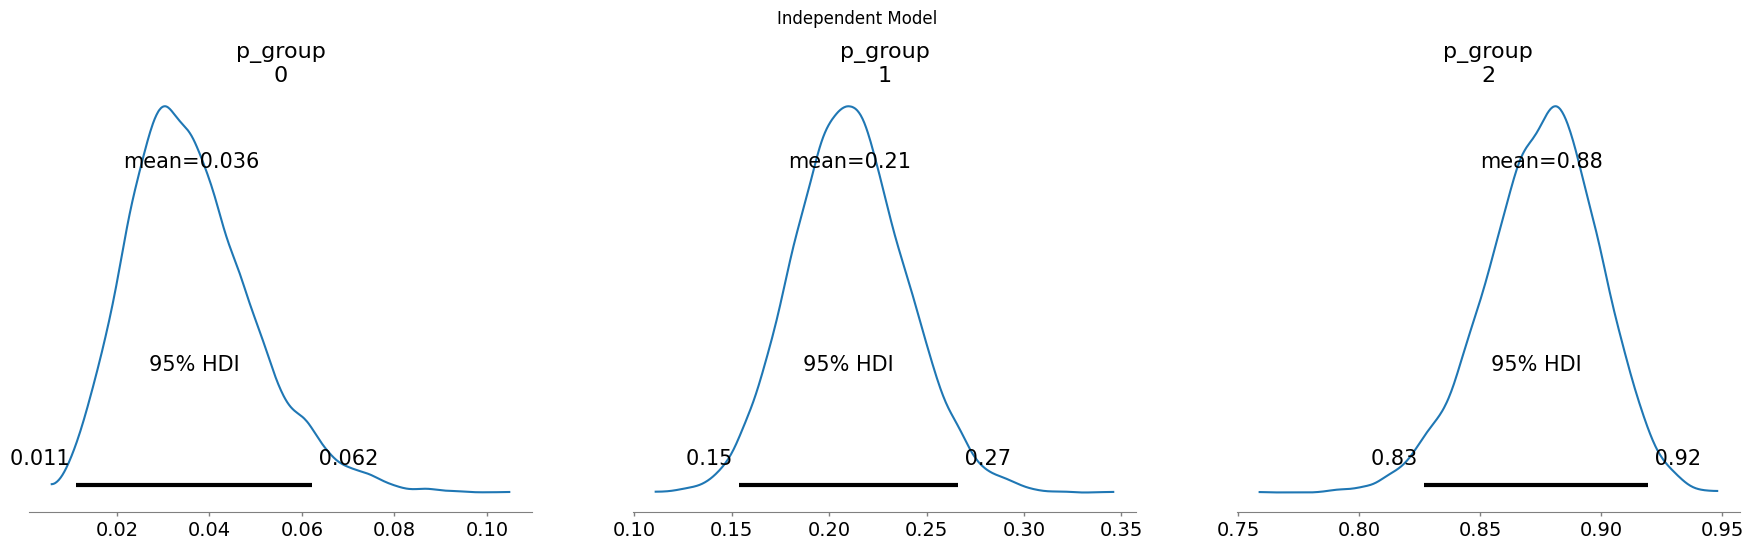

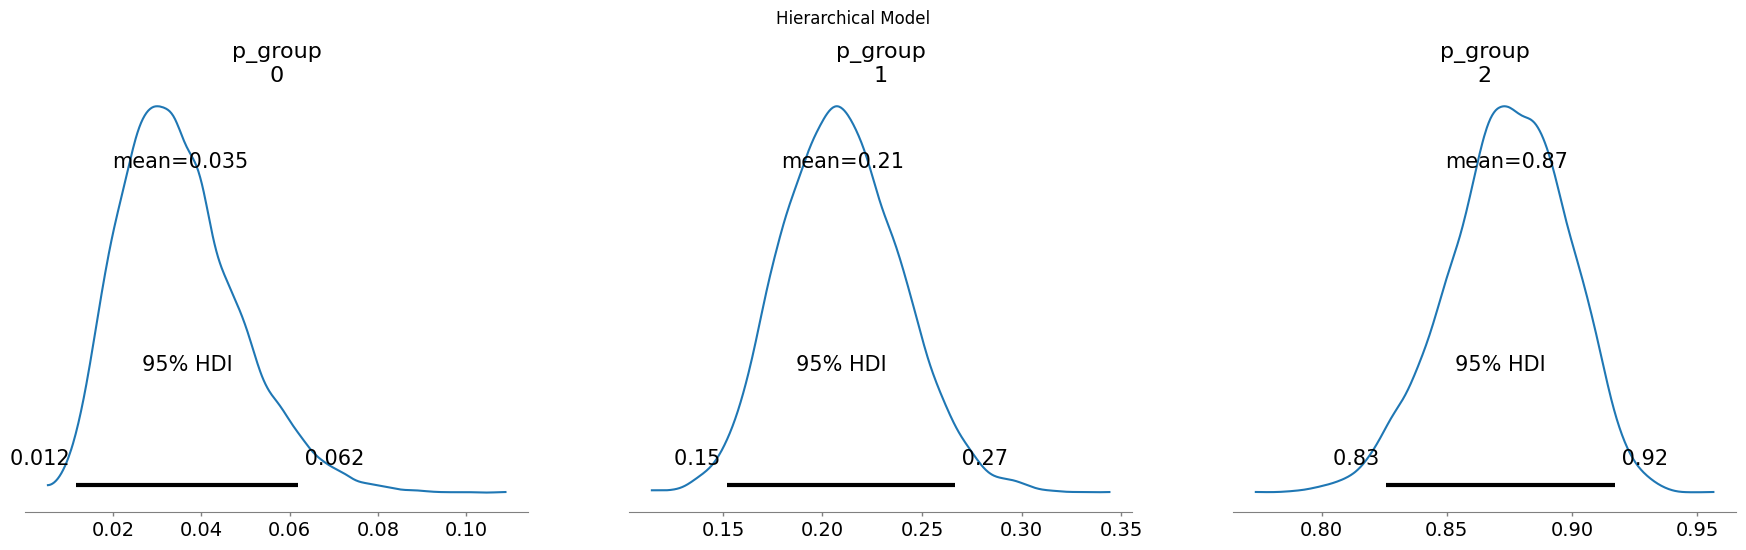

In [60]:
az.plot_posterior(
    idata_ind,
    var_names=["p_group"],
    hdi_prob=0.95
)
plt.suptitle("Independent Model", y=1.02)
plt.show()

az.plot_posterior(
    idata_h,
    var_names=["p_group"],
    hdi_prob=0.95
)
plt.suptitle("Hierarchical Model", y=1.02)
plt.show()

### Posterior Comparison – Interpretation

The posterior distributions from the independent and hierarchical models are very similar across all three radius groups.

Only a small amount of shrinkage is visible, especially for the Small and Large groups.

This suggests that the hierarchical structure has only a limited effect on the group estimates because each group contains a relatively large number of observations.

In [61]:
ind_means = (
    idata_ind.posterior["p_group"]
    .mean(dim=("chain", "draw"))
    .values
)

hier_means = (
    idata_h.posterior["p_group"]
    .mean(dim=("chain", "draw"))
    .values
)

comparison = pd.DataFrame({
    "Group": group_names,
    "Independent": ind_means,
    "Hierarchical": hier_means
})

comparison["Shrinkage"] = (
    comparison["Hierarchical"] -
    comparison["Independent"]
)

comparison

,Group,Independent,Hierarchical,Shrinkage
0,Small,0.036175,0.035175,-0.001000
1,Medium,0.210430,0.209886,-0.000544
2,Large,0.875218,0.874026,-0.001192


### Shrinkage Comparison

The hierarchical and independent estimates are almost identical.

Only very small changes are observed between the two models, indicating minimal shrinkage in this dataset.

This is likely because each radius group contains many observations, so the group-specific estimates are already strongly informed by their own data.

## 8. Model Comparison with WAIC

### AI Question

**What is WAIC, and how can it be used to compare Bayesian models with different structures? How should differences in `elpd_waic`, `p_waic`, model rank, and uncertainty be interpreted? Why do Bayesian model comparison methods use an effective number of parameters, and is BIC generally appropriate for Bayesian model comparison?**

In [62]:
waic_comparison = az.compare(
    {
        "Independent": idata_ind,
        "Hierarchical": idata_h
    },
    ic="waic"
)

waic_comparison

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Independent,0,-195.729729,2.882303,0.000000,1.000000e+00,14.728967,0.000000,False,log
Hierarchical,1,-195.808482,2.977445,0.078753,4.440892e-16,14.759711,0.100219,False,log


### WAIC Interpretation

The independent model is ranked first by WAIC and has a slightly higher
`elpd_waic` than the hierarchical model.

However, the difference between the two models is very small, indicating
that their predictive performance is essentially similar for this dataset.

This is consistent with the earlier finding that the hierarchical model
produced very little shrinkage because each group already contains many
observations.

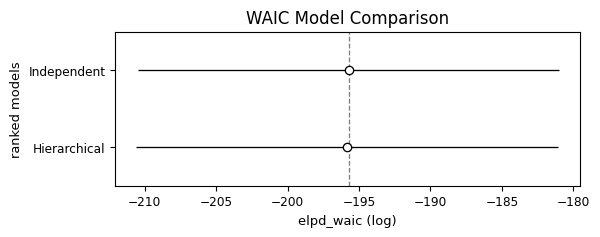

In [63]:
az.plot_compare(waic_comparison)
plt.title("WAIC Model Comparison")
plt.show()

## Conclusion

This notebook demonstrated Bayesian analysis using the Breast Cancer Wisconsin dataset.

A Beta-Bernoulli model was first used to estimate the probability of a malignant tumor. The analytical posterior and the PyMC MCMC posterior produced nearly identical results, with a posterior mean of approximately 0.373.

Sequential Bayesian updating showed how the posterior changes as observations are accumulated and confirmed that processing the data sequentially leads to the same final posterior, \(Beta(213,358)\), as processing all observations at once.

The Bayesian estimate was compared with classical confidence intervals, including a bootstrap confidence interval, and the different approaches produced very similar numerical results.

Posterior predictive sampling showed that the observed malignant count was consistent with outcomes generated by the Bayesian model.

Bayesian and classical hypothesis testing both provided evidence that the modeled malignant probability differs from 0.5. An analytical Savage-Dickey calculation was also used to check the numerical Bayes Factor estimate and demonstrated the importance of critically evaluating numerical warnings and approximation results.

The analysis was then extended to three mean-radius groups. A classical chi-square test showed a strong association between radius group and malignancy, while the Bayesian models estimated substantially different malignant probabilities across the three groups.

Independent and hierarchical Bayesian models produced very similar group estimates, with only minimal shrinkage because each group contained many observations.

Finally, WAIC indicated very similar predictive performance for the independent and hierarchical models, so the small difference in model ranking should not be interpreted as strong evidence that one model is clearly superior.

Overall, the notebook demonstrates how Bayesian inference can combine prior distributions, sequential updating, posterior uncertainty, MCMC, posterior prediction, Bayes estimators, hierarchical modeling, shrinkage, and Bayesian model comparison, while also allowing direct comparison with classical statistical methods.

### Limitations

The Breast Cancer Wisconsin dataset is a diagnostic dataset and should not be interpreted as a random sample of the general population. Therefore, the estimated malignant probability describes the statistical model for these data and should not be interpreted as the population prevalence of breast cancer.

The Small, Medium, and Large radius groups were created using quantiles of mean radius for the purpose of this analysis. They are not clinical categories or medical thresholds.

In addition, the hierarchical model treats the three radius groups as groups that can share information through a common distribution. Because these groups were deliberately created from ordered ranges of the same variable, the exchangeability assumption is a modeling simplification and should be interpreted cautiously.